# Applied Project in Big Data on Industrial Dataset

## Topic 2. Data processing and Exploratory Data Analysis (EDA)
### Example: YData Profiling demo

### 1. Libraries

In [1]:
!pip install -U ydata-profiling

  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.18.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached typeguard-4.4.4-py3-none-any.whl.metadata (3.3 kB)
  Using cached dacite-1.9.2-py3-none-any.whl.metadata (17 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached puremagic-1.30-py3-none-any.whl.metadata (5.8 kB)
Using cached dacite-1.9.2-py3-none-any.whl (16 kB)
Using cached filetype-1.2.0-py2.py3-none-any.whl (19 kB)
Using cached minify_html-0.18.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.1 MB)
Using cached multimethod-1.12-py3-none-any.whl (10 kB)
Using cached phik-0.12.5-cp312-cp312-manylinux_2_24_x86

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

from ydata_profiling import ProfileReport

### 2. H&M project EDA

#### 2.1. Read data

In [69]:
DATA_PATH = Path("/home/jovyan/__DATA/APBDID_F25/data")

In [70]:
project = "handm"
file_name = "articles.csv"

In [71]:
file_path = DATA_PATH / project / file_name
articles_df = pd.read_csv(file_path)

In [72]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
article_id,105542.0,6.984246e+08,1.284624e+08,108775015.0,616992501.0,702213001.5,7.967030e+08,959461001.0
product_code,105542.0,6.984246e+05,1.284624e+05,108775.0,616992.5,702213.0,7.967030e+05,959461.0
product_type_no,105542.0,2.348619e+02,7.504931e+01,-1.0,252.0,259.0,2.720000e+02,762.0
graphical_appearance_no,105542.0,1.009515e+06,2.241359e+04,-1.0,1010008.0,1010016.0,1.010016e+06,1010029.0
colour_group_code,105542.0,3.223382e+01,2.808615e+01,-1.0,9.0,14.0,5.200000e+01,93.0
perceived_colour_value_id,105542.0,3.206183e+00,1.563839e+00,-1.0,2.0,4.0,4.000000e+00,7.0
perceived_colour_master_id,105542.0,7.807972e+00,5.376727e+00,-1.0,4.0,5.0,1.100000e+01,20.0
department_no,105542.0,4.532778e+03,2.712692e+03,1201.0,1676.0,4222.0,7.389000e+03,9989.0
index_group_no,105542.0,3.171534e+00,4.353234e+00,1.0,1.0,2.0,4.000000e+00,26.0
section_no,105542.0,4.266422e+01,2.326010e+01,2.0,20.0,46.0,6.100000e+01,97.0


In [9]:
df.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


#### 2.2. Get some help from AI

Try using folowwing prompt:

```
Take Pandas dataframe with the structure below and provide an exploratory data analysis with Python code
1. Use pandas for data manipulation, seaborn for advanced plots, and matplotlib for customization
2. Give a description of data based on columns names
3. Data is taken from H&M dataset and describes articles that are sold


---
Dataframe info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13  perceived_colour_master_name  105542 non-null  object
 14  department_no                 105542 non-null  int64 
 15  department_name               105542 non-null  object
 16  index_code                    105542 non-null  object
 17  index_name                    105542 non-null  object
 18  index_group_no                105542 non-null  int64 
 19  index_group_name              105542 non-null  object
 20  section_no                    105542 non-null  int64 
 21  section_name                  105542 non-null  object
 22  garment_group_no              105542 non-null  int64 
 23  garment_group_name            105542 non-null  object
 24  detail_desc                   105126 non-null  object
dtypes: int64(11), object(14)
```

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [11]:
print("=== DATA OVERVIEW ===")
print(f"Total Articles: {len(df):,}")
print(f"Number of Columns: {df.shape[1]}")
print(f"Missing Values in detail_desc: {df['detail_desc'].isnull().sum()}")

# Check for duplicates
print(f"Duplicate articles: {df['article_id'].duplicated().sum()}")

=== DATA OVERVIEW ===
Total Articles: 105,542
Number of Columns: 25
Missing Values in detail_desc: 416
Duplicate articles: 0


In [12]:
print("=== DATA QUALITY CHECK ===")
# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info[missing_info['Missing Count'] > 0])

# Check basic statistics for numerical columns
print("\nNumerical Columns Statistics:")
display(df.describe())

=== DATA QUALITY CHECK ===
             Missing Count  Missing Percentage
detail_desc            416            0.394156

Numerical Columns Statistics:


,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no
count,1.055420e+05,105542.000000,105542.000000,1.055420e+05,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000
mean,6.984246e+08,698424.563378,234.861875,1.009515e+06,32.233822,3.206183,7.807972,4532.777833,3.171534,42.664219,1010.438290
std,1.284624e+08,128462.384432,75.049308,2.241359e+04,28.086154,1.563839,5.376727,2712.692011,4.353234,23.260105,6.731023
min,1.087750e+08,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000
25%,6.169925e+08,616992.500000,252.000000,1.010008e+06,9.000000,2.000000,4.000000,1676.000000,1.000000,20.000000,1005.000000
50%,7.022130e+08,702213.000000,259.000000,1.010016e+06,14.000000,4.000000,5.000000,4222.000000,2.000000,46.000000,1009.000000
75%,7.967030e+08,796703.000000,272.000000,1.010016e+06,52.000000,4.000000,11.000000,7389.000000,4.000000,61.000000,1017.000000
max,9.594610e+08,959461.000000,762.000000,1.010029e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000


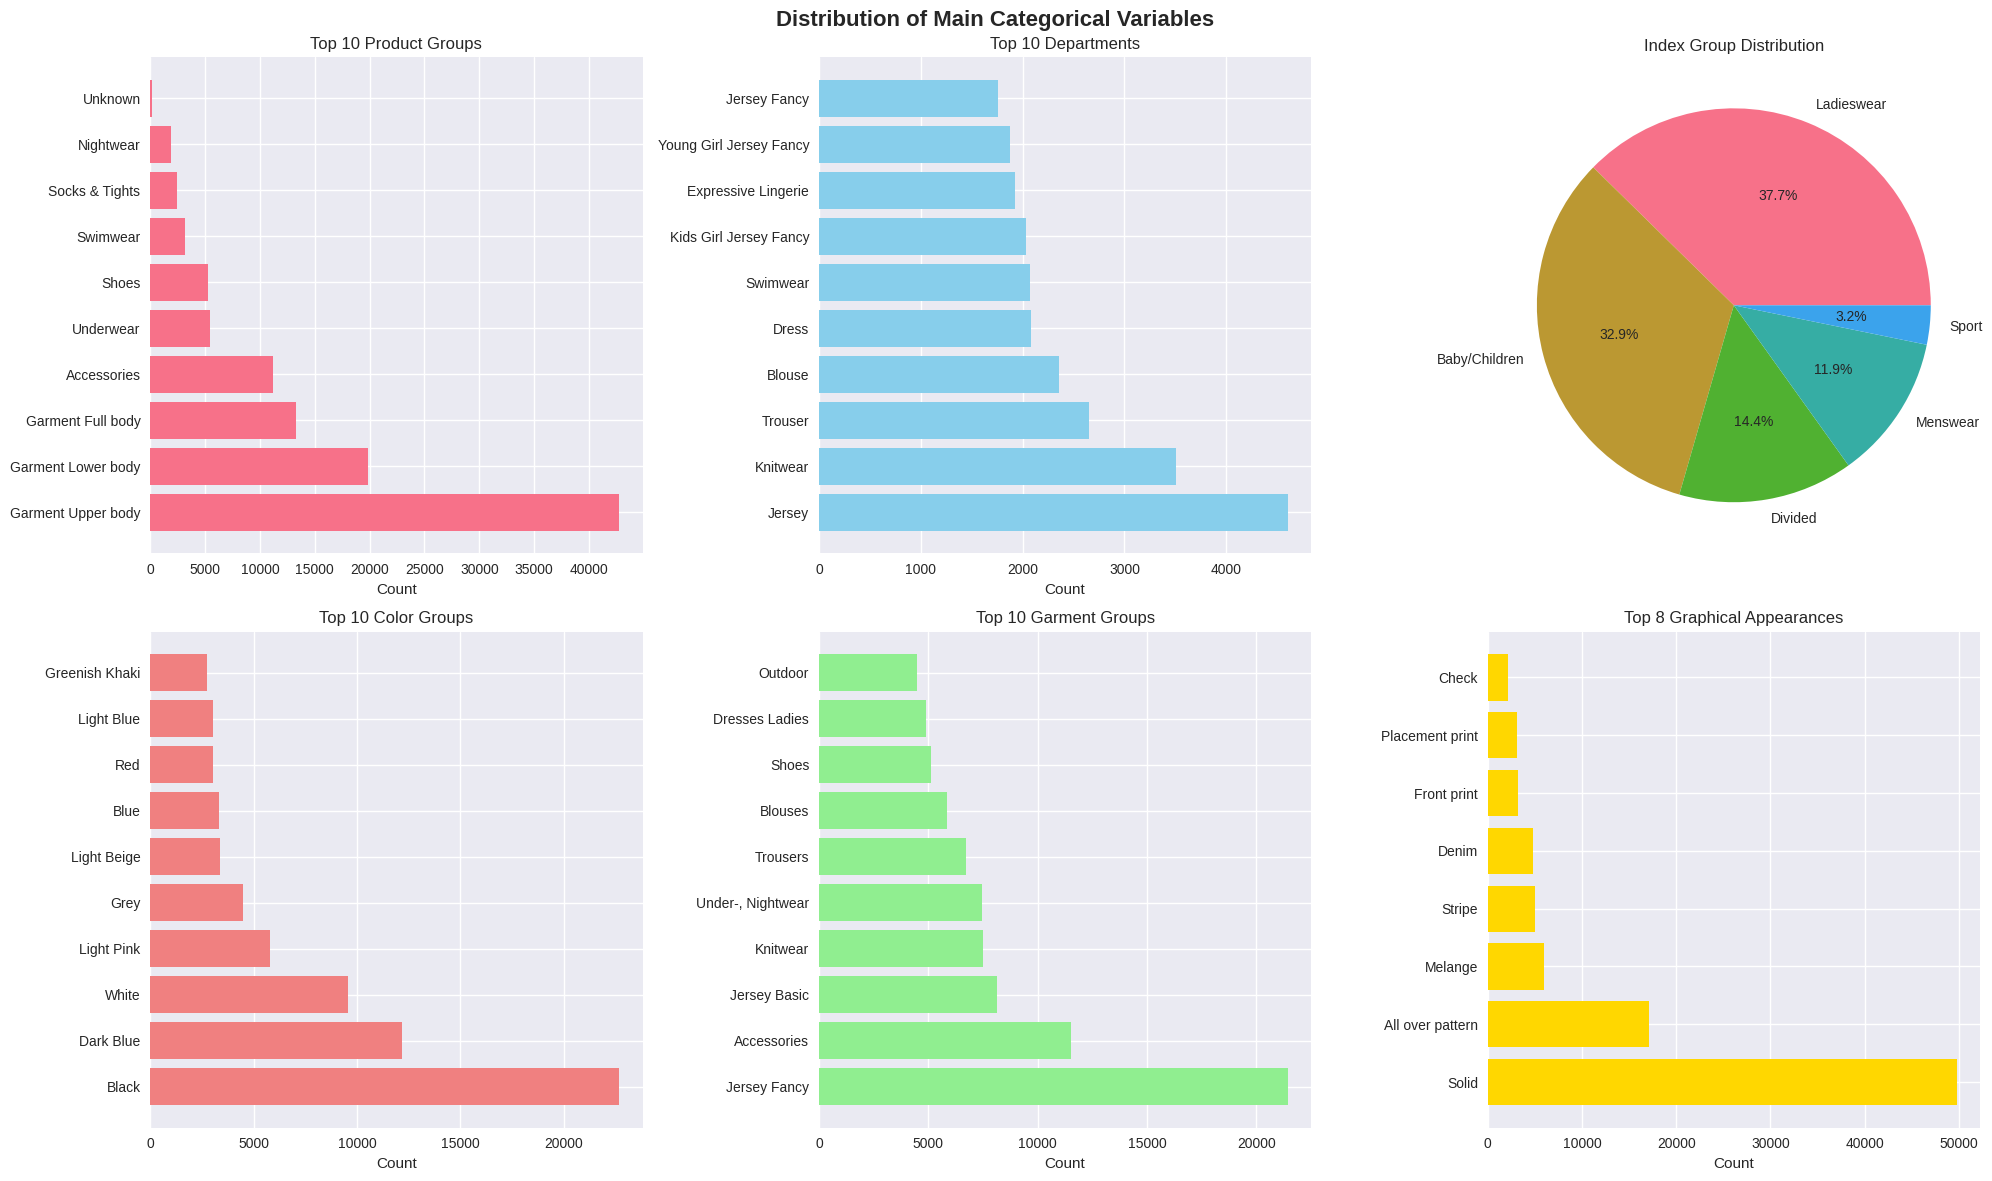

In [13]:
# Set up the figure for categorical analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Distribution of Main Categorical Variables', fontsize=16, fontweight='bold')

# Product Group Distribution
product_group_counts = df['product_group_name'].value_counts().head(10)
axes[0,0].barh(product_group_counts.index, product_group_counts.values)
axes[0,0].set_title('Top 10 Product Groups')
axes[0,0].set_xlabel('Count')

# Department Distribution
dept_counts = df['department_name'].value_counts().head(10)
axes[0,1].barh(dept_counts.index, dept_counts.values, color='skyblue')
axes[0,1].set_title('Top 10 Departments')
axes[0,1].set_xlabel('Count')

# Index Group Distribution
index_counts = df['index_group_name'].value_counts()
axes[0,2].pie(index_counts.values, labels=index_counts.index, autopct='%1.1f%%')
axes[0,2].set_title('Index Group Distribution')

# Color Group Distribution
color_counts = df['colour_group_name'].value_counts().head(10)
axes[1,0].barh(color_counts.index, color_counts.values, color='lightcoral')
axes[1,0].set_title('Top 10 Color Groups')
axes[1,0].set_xlabel('Count')

# Garment Group Distribution
garment_counts = df['garment_group_name'].value_counts().head(10)
axes[1,1].barh(garment_counts.index, garment_counts.values, color='lightgreen')
axes[1,1].set_title('Top 10 Garment Groups')
axes[1,1].set_xlabel('Count')

# Graphical Appearance Distribution
graphical_counts = df['graphical_appearance_name'].value_counts().head(8)
axes[1,2].barh(graphical_counts.index, graphical_counts.values, color='gold')
axes[1,2].set_title('Top 8 Graphical Appearances')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [14]:
print("=== PRODUCT TYPE ANALYSIS ===")
product_type_summary = df.groupby('product_type_name').agg({
    'article_id': 'count',
    'product_group_name': 'first'
}).sort_values('article_id', ascending=False).head(15)
product_type_summary.columns = ['article_count', 'product_group']
print("Top 15 Product Types:")
display(product_type_summary)

# Color Analysis
print("\n=== COLOR ANALYSIS ===")
color_analysis = df.groupby(['colour_group_name', 'perceived_colour_master_name']).size().reset_index(name='count')
color_analysis = color_analysis.sort_values('count', ascending=False).head(15)
print("Top Color Combinations:")
display(color_analysis)

=== PRODUCT TYPE ANALYSIS ===
Top 15 Product Types:


,article_count,product_group
product_type_name,,
Trousers,11169,Garment Lower body
Dress,10362,Garment Full body
Sweater,9302,Garment Upper body
T-shirt,7904,Garment Upper body
Top,4155,Garment Upper body
Blouse,3979,Garment Upper body
Jacket,3940,Garment Upper body
Shorts,3939,Garment Lower body
Shirt,3405,Garment Upper body



=== COLOR ANALYSIS ===
Top Color Combinations:


,colour_group_name,perceived_colour_master_name,count
3,Black,Black,22331
15,Dark Blue,Blue,12008
146,White,White,9374
96,Light Pink,Pink,5794
67,Grey,Grey,4369
7,Blue,Blue,3273
137,Red,Red,3008
77,Light Blue,Blue,2999
63,Greenish Khaki,Khaki green,2738
73,Light Beige,Beige,2711


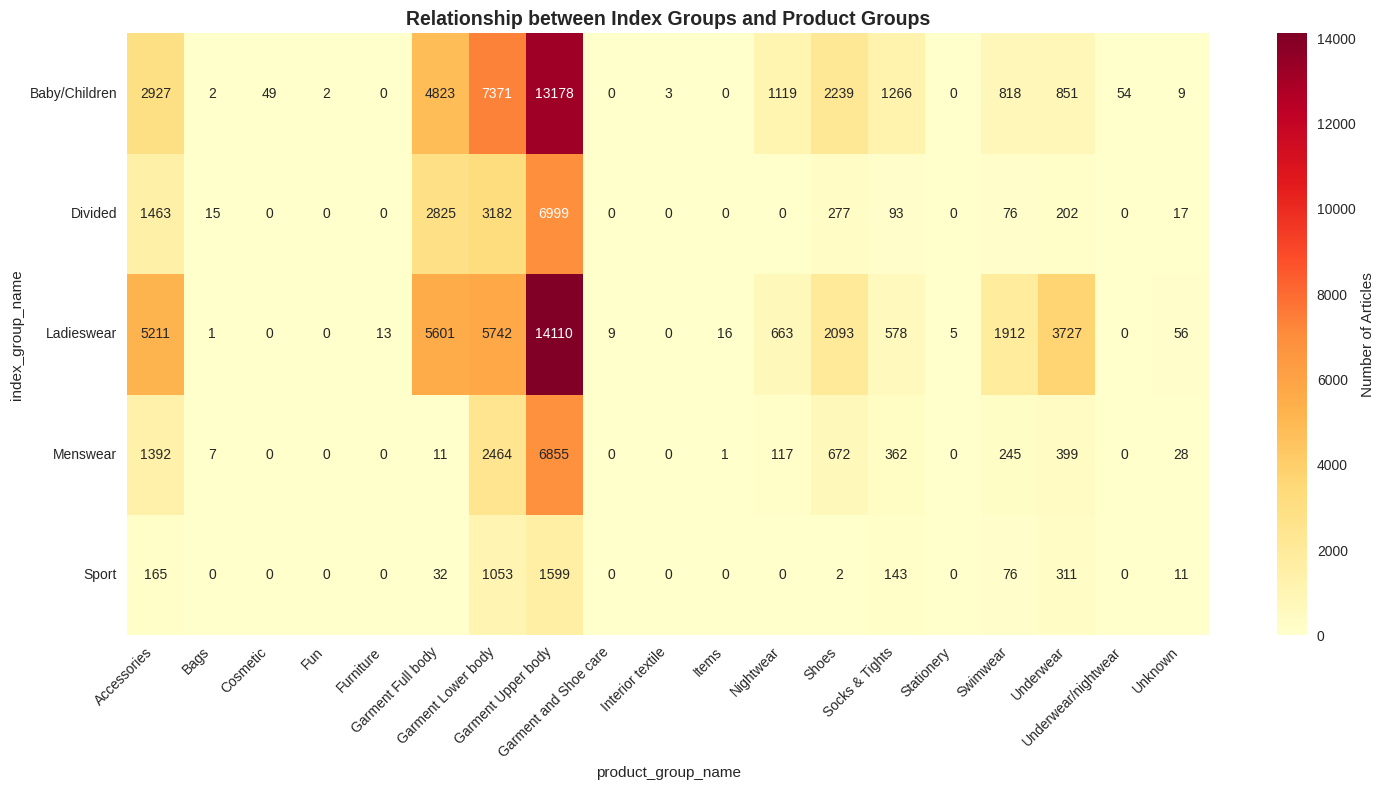

In [15]:
# Relationship between Index Group and Product Group
plt.figure(figsize=(15, 8))
cross_tab = pd.crosstab(df['index_group_name'], df['product_group_name'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Articles'})
plt.title('Relationship between Index Groups and Product Groups', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

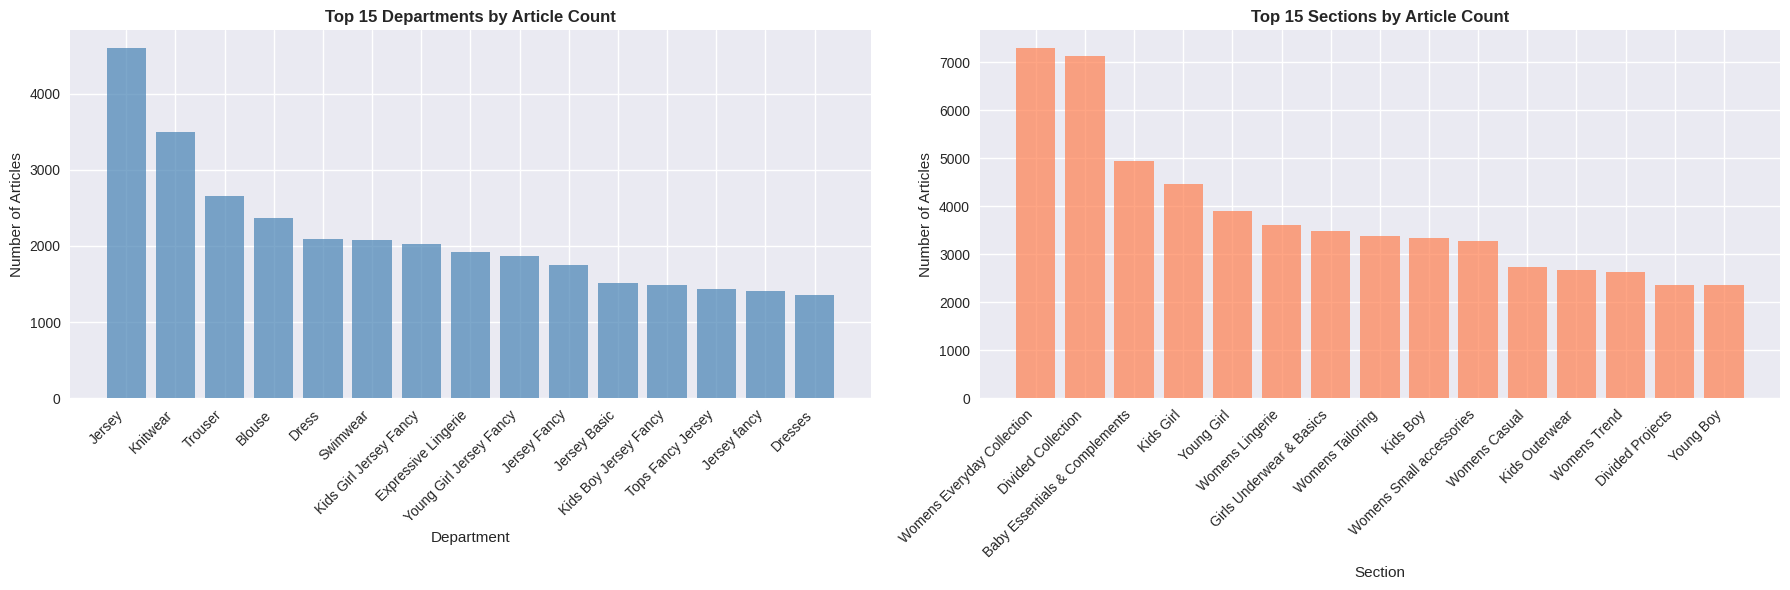

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Department distribution
dept_data = df['department_name'].value_counts().head(15)
ax1.bar(range(len(dept_data)), dept_data.values, color='steelblue', alpha=0.7)
ax1.set_title('Top 15 Departments by Article Count', fontweight='bold')
ax1.set_xlabel('Department')
ax1.set_ylabel('Number of Articles')
ax1.set_xticks(range(len(dept_data)))
ax1.set_xticklabels(dept_data.index, rotation=45, ha='right')

# Section distribution
section_data = df['section_name'].value_counts().head(15)
ax2.bar(range(len(section_data)), section_data.values, color='coral', alpha=0.7)
ax2.set_title('Top 15 Sections by Article Count', fontweight='bold')
ax2.set_xlabel('Section')
ax2.set_ylabel('Number of Articles')
ax2.set_xticks(range(len(section_data)))
ax2.set_xticklabels(section_data.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

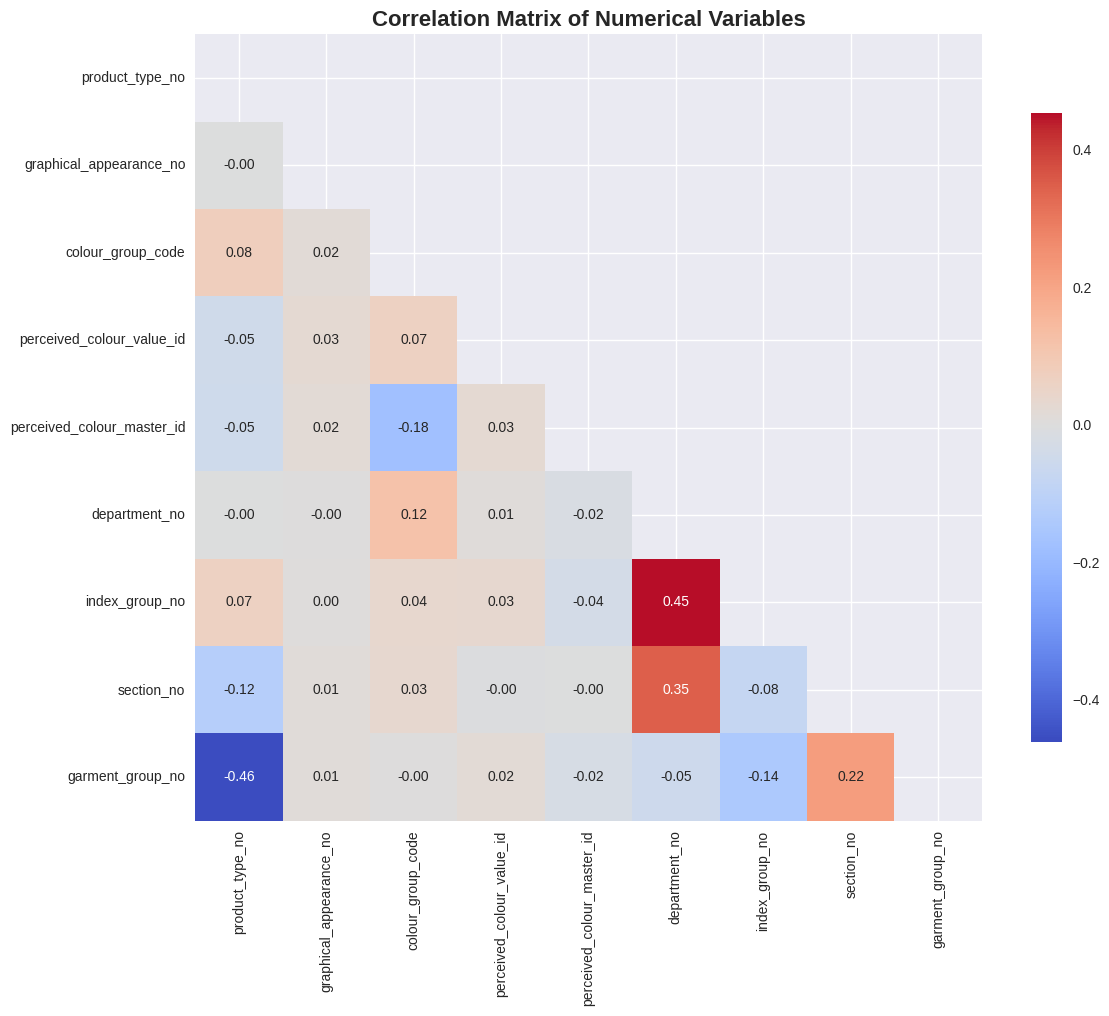

In [17]:
# Select numerical columns for correlation
numerical_cols = ['product_type_no', 'graphical_appearance_no', 'colour_group_code', 
                  'perceived_colour_value_id', 'perceived_colour_master_id', 
                  'department_no', 'index_group_no', 'section_no', 'garment_group_no']

plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, square=True, fmt='.2f', 
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.3. Profile data with YData

In [ ]:
profile = ProfileReport(
    df,
    title="YData Profiling Report"
)

In [ ]:
profile

## Customers

In [28]:
file_name = "customers.csv"

In [32]:
customers_df = pd.read_csv(file_path)

In [34]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


In [47]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


In [64]:
customers_df.sample(5)

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
866840,a1ccc9f72ec7b86210c415da25aaf218b7325ee76ee7c0...,NaN,NaN,NaN,NONE,53.0,de2b9ebf3821341ee93faeedc238e9e33147eddcd49c31...
191827,23c017f73eb028bb1fb3a25469b3274dbd0419a6d9d462...,NaN,NaN,ACTIVE,NONE,19.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...
735807,895998e2e35fa75a37edca9e937cc053ae0d824b069011...,NaN,NaN,ACTIVE,NONE,52.0,6de2c3074ed75eb2dd1b81735c16051f08302df91768cf...
550214,66b43d39d345cb4e37eb3aab09ac07fff0210cb59ee251...,NaN,NaN,ACTIVE,NONE,25.0,00e36c5d377909a4e321626f46b01d256219f50a5351c2...
577865,6bd31f8d663bab44b511f48cae12f21cea757d858372a0...,NaN,NaN,ACTIVE,NONE,61.0,b80b101ab59593ccfc91b7f53b4fc7c7e5d961f7441538...


=== COLUMN GUIDE ===


,column,meaning
0,customer_id,Unique customer identifier (hashed). Used as j...
1,FN,Flag-like field (often 1/NaN). Interpretable a...
2,Active,Flag-like field (often 1/NaN). Interpretable a...
3,club_member_status,"Loyalty club membership status (e.g., ACTIVE, ..."
4,fashion_news_frequency,How often the customer receives fashion news (...
5,age,Customer age (float in raw data; should be tre...
6,postal_code,Postal code (hashed / anonymized). High-cardin...


=== SHAPE / TYPES ===
Rows: 1,371,980
Cols: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


None


=== SAMPLE ===


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
1134822,d3b658f59ad9bbf6249a7bf0db722f2f43cc47803d0329...,NaN,NaN,ACTIVE,NONE,72.0,da477e6d8c015e8d89487ae038b1be611c052834008252...
612735,72529945a566eb7445e51470ef00c5992976ddaf7d9f82...,NaN,NaN,ACTIVE,NONE,41.0,c9d1dd747df26b6fd8a8d682f1f0ed3db12bfc7041e49a...
1124456,d1c91a9050fcb6da04f0643c6b6d38b002b6ff12d66e80...,NaN,NaN,ACTIVE,NONE,22.0,760fd89d83df7842c04f3a6d68265270bc2333c43cabf7...
662579,7bad01c1ad7a9bccc9270a29bf24279b4e19b41afc1b4a...,1.0,NaN,ACTIVE,Regularly,24.0,032fdbc74a7144e1bcbc2addc9d5c8a0d8f39223754aac...
404009,4b889f848f59f9bf787b16626f96d0390c3f9ab3ed3edc...,NaN,NaN,ACTIVE,NONE,56.0,a0f3f7d2ae3b89be98d44524b3a6743c1916986e507ef9...



=== MISSINGNESS (non-zero only) ===


,missing_count,missing_pct
Active,907576,66.150819
FN,895050,65.237831
fashion_news_frequency,16011,1.167000
age,15861,1.156066
club_member_status,6062,0.441843


Duplicate customer_id rows: 0

=== CARDINALITY (nunique, dropna=True) ===


,nunique
customer_id,1371980
postal_code,352899
age,84
fashion_news_frequency,3
club_member_status,3
Active,1
FN,1


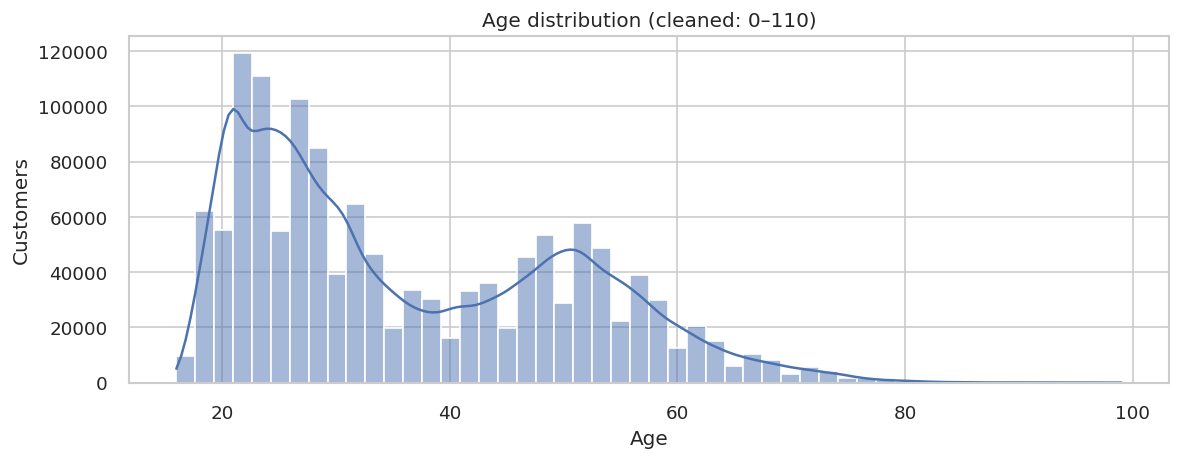

=== AGE SUMMARY (cleaned) ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age_clean,1356119.0,36.386965,14.313628,16.0,18.0,19.0,24.0,32.0,49.0,62.0,71.0,99.0


=== FN DISTRIBUTION ===


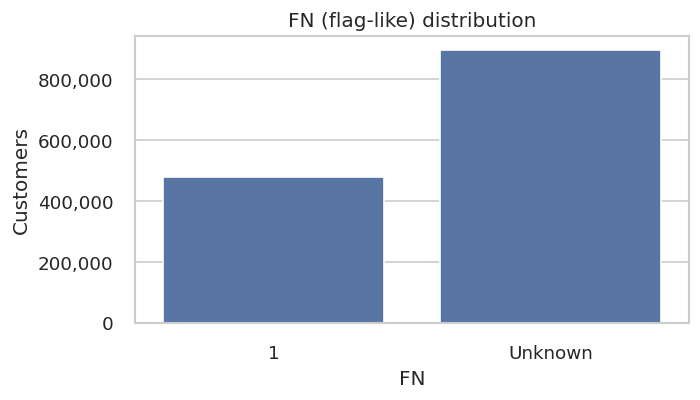

,FN,count,pct
0,1,476930,34.762169
1,Unknown,895050,65.237831


=== Active DISTRIBUTION ===


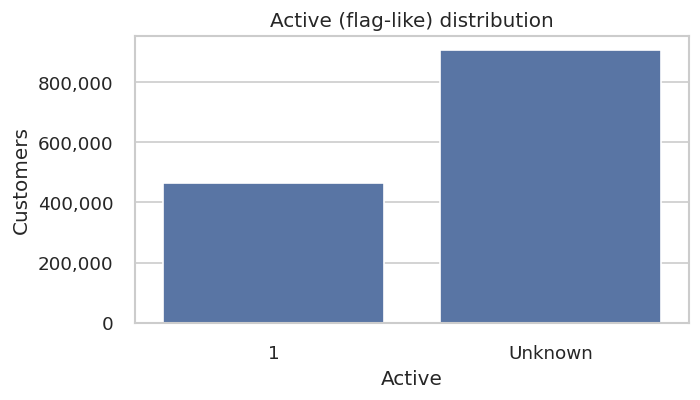

,Active,count,pct
0,1,464404,33.849181
1,Unknown,907576,66.150819


=== CLUB MEMBER STATUS ===


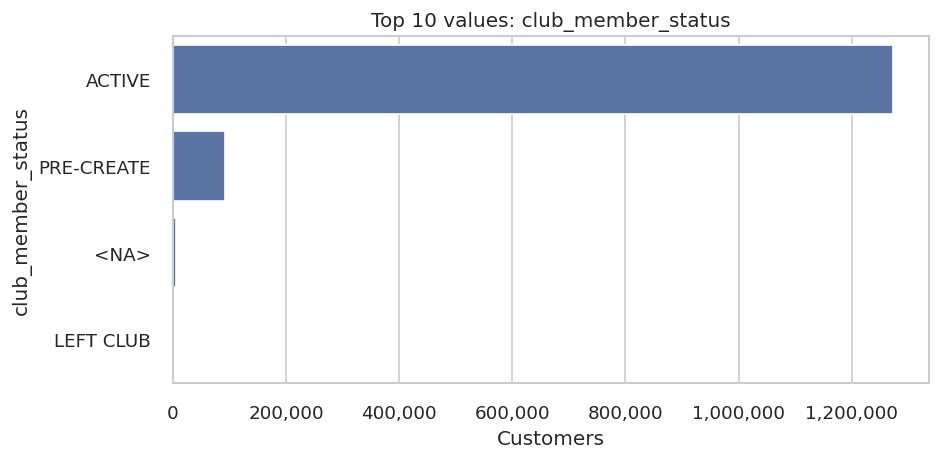

,count,pct
club_member_status,,
ACTIVE,1272491,92.748509
PRE-CREATE,92960,6.775609
<NA>,6062,0.441843
LEFT CLUB,467,0.034038


=== FASHION NEWS FREQUENCY ===


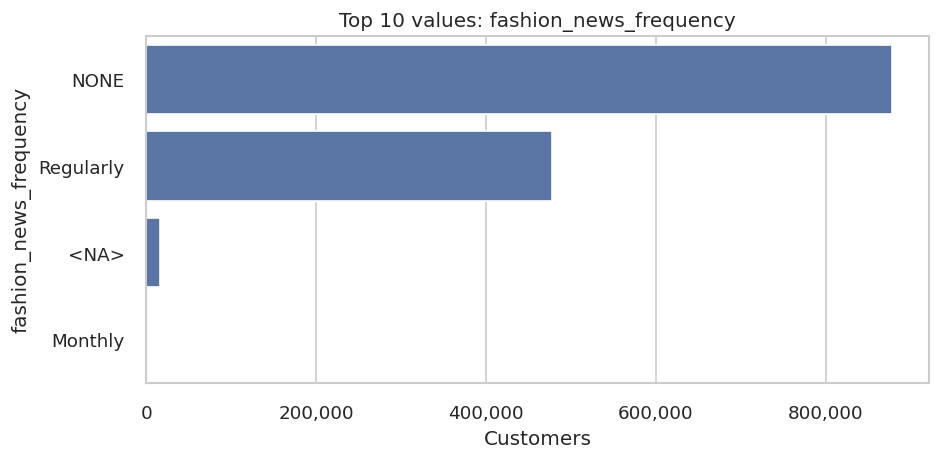

,count,pct
fashion_news_frequency,,
NONE,877711,63.974038
Regularly,477416,34.797592
<NA>,16011,1.167
Monthly,842,0.061371


=== POSTAL CODE CARDINALITY ===
Unique postal_code values: 352,899
Top 10 postal codes by count (anonymized):


,count,pct
postal_code,,
2c29ae653a9282cce4151bd87643c907644e09541abc28ae87dea0d1f6603b1c,120303,8.768568
cc4ed85e30f4977dae47662ddc468cd2eec11472de6fac5ec985080fd92243c8,261,0.019024
714976379549eb90aae4a71bca6c7402cc646ae7c40f6c1cb91d4b5a18623fc1,159,0.011589
7c1fa3b0ec1d37ce2c3f34f63bd792f3b4494f324b6be5d1e4ba6a75456b96a7,157,0.011443
5b7eb31eabebd3277de632b82267286d847fd5d44287ee150bb4206b48439145,156,0.011370
1f5bd429acc88fbbf24de844a59e438704aa8761bc7b99fd977cad297c50b74c,154,0.011225
9d5787501bf1c77592156ba51eab13f4a2670c807686431a9e22a69090b02358,141,0.010277
a1959a16bf167858c93a66ec2a330644512b25fb10f97eee2058549885af4dbd,138,0.010058
087a46b65170845b4a55226ff1eb748ce7843d4b637cbe17f6bfbd1e645d2ffb,134,0.009767


Postal-code concentration proxy (HHI): 0.007693 (higher means more concentrated)


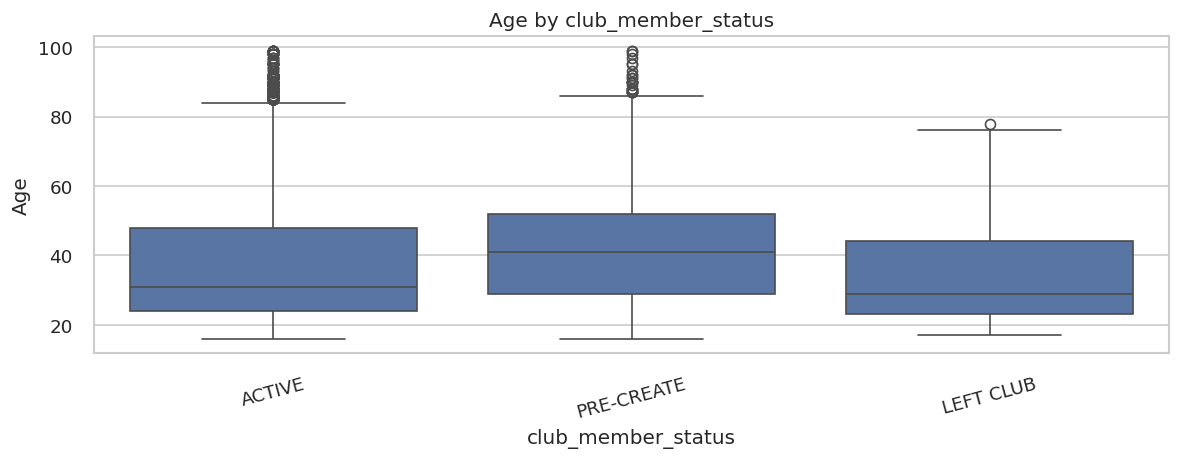

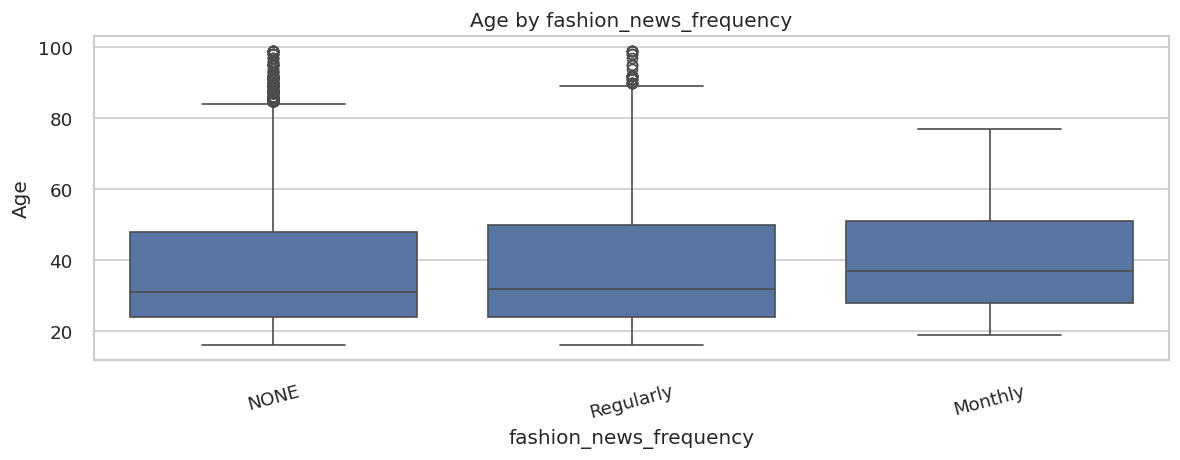

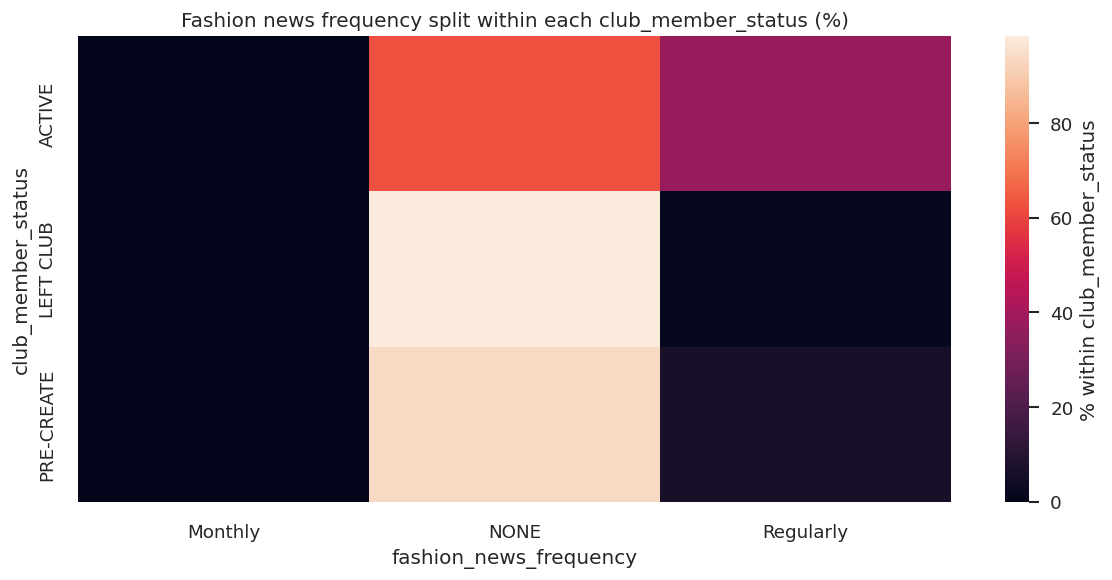

fashion_news_frequency,Monthly,NONE,Regularly
club_member_status,,,
ACTIVE,0.06,62.55,37.39
LEFT CLUB,0.00,98.29,1.71
PRE-CREATE,0.06,93.57,6.37


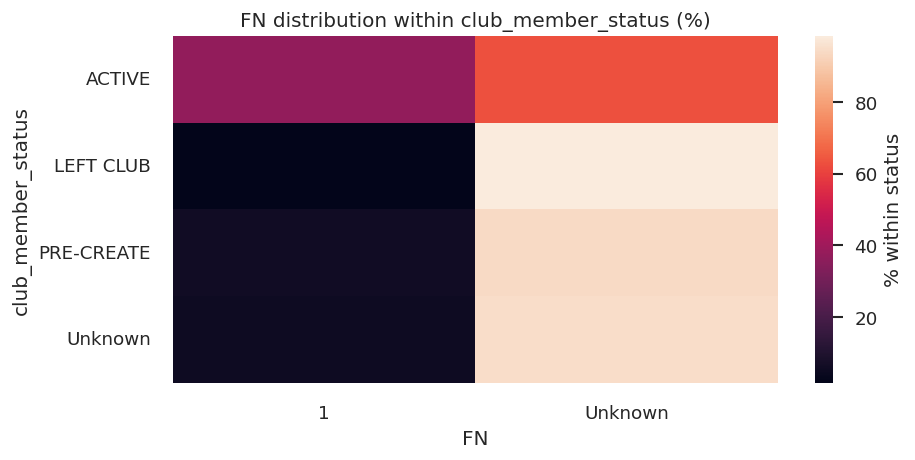

FN,1,Unknown
club_member_status,,
ACTIVE,37.00,63.00
LEFT CLUB,1.71,98.29
PRE-CREATE,6.21,93.79
Unknown,5.30,94.70


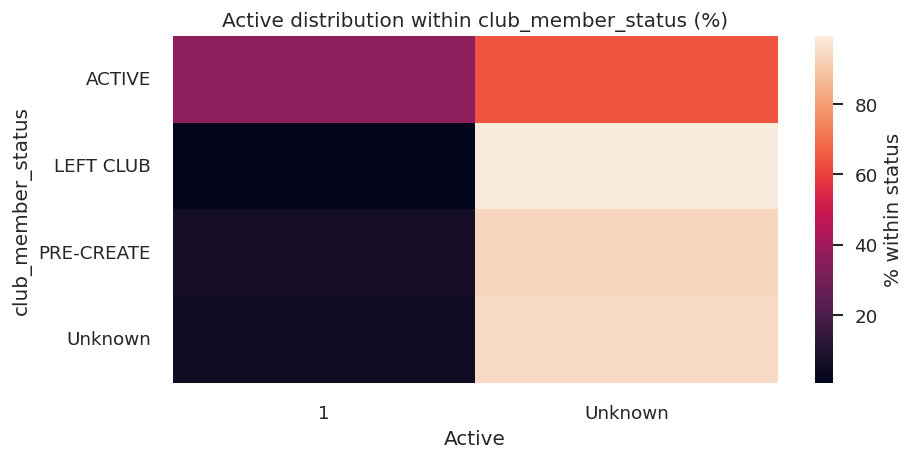

Active,1,Unknown
club_member_status,,
ACTIVE,36.03,63.97
LEFT CLUB,0.64,99.36
PRE-CREATE,6.06,93.94
Unknown,5.25,94.75


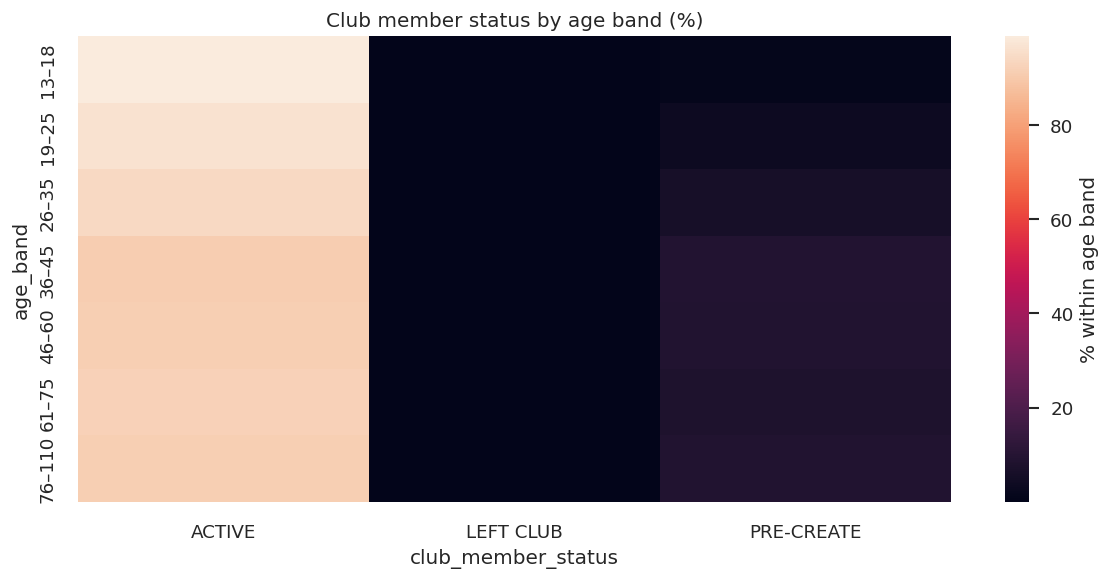

club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE
age_band,,,
13–18,98.82,0.07,1.11
19–25,96.48,0.04,3.48
26–35,93.81,0.04,6.16
36–45,91.06,0.03,8.91
46–60,91.45,0.03,8.53
61–75,91.88,0.02,8.09
76–110,91.12,0.05,8.83


=== ONE-PAGE SUMMARY ===


,rows,unique_customers,missing_FN_pct,missing_Active_pct,missing_age_pct,missing_club_member_status_pct,missing_fashion_news_frequency_pct,unique_postal_codes
0,1371980,1371980,65.237831,66.150819,1.156066,0.441843,1.167,352899


In [51]:
df = customers_df.copy()

# FN/Active: present means 1, missing means 0 in this dataset
df["FN_flag"] = (df["FN"] == 1).fillna(False).astype(int)
df["Active_flag"] = (df["Active"] == 1).fillna(False).astype(int)

# club member status: explicit unknown
df["club_member_status"] = df["club_member_status"].astype("string").fillna("UNKNOWN").str.strip()

# fashion news: explicit unknown + normalize
df["fashion_news_frequency"] = df["fashion_news_frequency"].astype("string").fillna("UNKNOWN").str.strip()

# age
df["age"] = df["age"].astype("Float64")
df["age_missing"] = df["age"].isna().astype(int)
df["age_clean"] = df["age"].where(df["age"].between(0, 110))

# postal code: collapse dominant code into a sentinel bucket
top_postal = df["postal_code"].value_counts().idxmax()
df["postal_code_clean"] = df["postal_code"].where(df["postal_code"] != top_postal, "__UNKNOWN_POSTAL__")

from matplotlib.ticker import PercentFormatter

# ---------- 0) Setup ----------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

df = customers_df.copy()

# ---------- 1) Column meanings (based on names / common H&M Kaggle schema) ----------
column_guide = pd.DataFrame(
    {
        "column": df.columns,
        "meaning": [
            "Unique customer identifier (hashed). Used as join key with transactions.",
            "Flag-like field (often 1/NaN). Interpretable as 'subscribed/flag FN' feature; missing means unknown/not set.",
            "Flag-like field (often 1/NaN). Interpretable as 'active customer' indicator; missing means unknown/not set.",
            "Loyalty club membership status (e.g., ACTIVE, PRE-CREATE, LEFT CLUB).",
            "How often the customer receives fashion news (e.g., Regularly, Monthly, NONE).",
            "Customer age (float in raw data; should be treated as numeric, often integer-like).",
            "Postal code (hashed / anonymized). High-cardinality location proxy."
        ],
    }
)

print("=== COLUMN GUIDE ===")
display(column_guide)

# ---------- 2) Basic overview ----------
print("=== SHAPE / TYPES ===")
print(f"Rows: {len(df):,}")
print(f"Cols: {df.shape[1]}")
display(df.info())

print("\n=== SAMPLE ===")
display(df.sample(5, random_state=42))

# Missingness summary
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)

print("\n=== MISSINGNESS (non-zero only) ===")
display(missing_tbl)

# Duplicate keys check
dup_customer_ids = df["customer_id"].duplicated().sum()
print(f"Duplicate customer_id rows: {dup_customer_ids:,}")

# Cardinality: high-cardinality columns are important for modeling and plotting choices
cardinality = df.nunique(dropna=True).sort_values(ascending=False)
print("\n=== CARDINALITY (nunique, dropna=True) ===")
display(cardinality.to_frame("nunique"))

# ---------- 3) Data cleaning for analysis (non-destructive) ----------
# FN and Active are float indicator columns; convert to nullable integer-like indicators {0/1/NA} if applicable.
# In H&M dataset these are typically 1.0 or NaN; sometimes 0.0 exists depending on preprocessing.
for col in ["FN", "Active"]:
    if col in df.columns:
        # Keep NA, but round values that look like flags
        df[col] = df[col].astype("Float64")
        # If values are only {1, 0, NA}, convert to Int64
        uniq = set(df[col].dropna().unique().tolist())
        if uniq.issubset({0.0, 1.0}):
            df[col] = df[col].astype("Int64")

# Normalize string categories (strip, uppercase where appropriate)
for col in ["club_member_status", "fashion_news_frequency"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Age: sensible range checks, and a cleaned version for plotting
df["age"] = df["age"].astype("Float64")
df["age_clean"] = df["age"].where(df["age"].between(0, 110))  # keep plausible human ages

# Optional: bucket ages (helpful for categorical summaries)
age_bins = [0, 12, 18, 25, 35, 45, 60, 75, 110]
age_labels = ["0–12", "13–18", "19–25", "26–35", "36–45", "46–60", "61–75", "76–110"]
df["age_band"] = pd.cut(df["age_clean"], bins=age_bins, labels=age_labels, include_lowest=True)

# ---------- 4) Univariate analysis ----------
# 4.1 Age distribution
plt.figure(figsize=(10, 4))
sns.histplot(df["age_clean"].dropna(), bins=50, kde=True)
plt.title("Age distribution (cleaned: 0–110)")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

# Age summary stats
print("=== AGE SUMMARY (cleaned) ===")
age_desc = df["age_clean"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T
display(age_desc)

# 4.2 Flag columns: FN / Active distributions (treating NA as 'unknown')
def plot_flag(col):
    if col not in df.columns:
        return
    tmp = df[col].copy()
    # Convert to categorical with explicit unknown
    tmp = tmp.astype("Int64")
    tmp = tmp.astype("string").fillna("Unknown")
    order = ["1", "0", "Unknown"] if set(tmp.unique()) & {"0"} else ["1", "Unknown"]
    counts = tmp.value_counts(dropna=False).reindex(order).dropna()

    plt.figure(figsize=(6, 3.5))
    ax = sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"{col} (flag-like) distribution")
    plt.xlabel(col)
    plt.ylabel("Customers")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
    plt.tight_layout()
    plt.show()

    # Percent table
    pct = (counts / len(df) * 100).to_frame("pct").reset_index(names=col)
    pct["count"] = counts.values
    pct = pct[[col, "count", "pct"]]
    display(pct)

print("=== FN DISTRIBUTION ===")
plot_flag("FN")
print("=== Active DISTRIBUTION ===")
plot_flag("Active")

# 4.3 club_member_status and fashion_news_frequency
def plot_top_categories(col, top_n=10):
    if col not in df.columns:
        return
    counts = df[col].value_counts(dropna=False).head(top_n)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(y=counts.index.astype(str), x=counts.values)
    plt.title(f"Top {top_n} values: {col}")
    plt.xlabel("Customers")
    plt.ylabel(col)
    ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
    plt.tight_layout()
    plt.show()

    out = (df[col].value_counts(dropna=False).rename("count").to_frame())
    out["pct"] = out["count"] / len(df) * 100
    display(out.head(top_n))

print("=== CLUB MEMBER STATUS ===")
plot_top_categories("club_member_status", top_n=10)

print("=== FASHION NEWS FREQUENCY ===")
plot_top_categories("fashion_news_frequency", top_n=10)

# 4.4 Postal code: high cardinality summary (avoid huge plots)
postal_nunique = df["postal_code"].nunique()
top_postal = df["postal_code"].value_counts().head(10).to_frame("count")
top_postal["pct"] = top_postal["count"] / len(df) * 100

print("=== POSTAL CODE CARDINALITY ===")
print(f"Unique postal_code values: {postal_nunique:,}")
print("Top 10 postal codes by count (anonymized):")
display(top_postal)

# Inequality check: how concentrated is postal_code? (quick Herfindahl index proxy)
p = df["postal_code"].value_counts(normalize=True)
hhi = (p ** 2).sum()
print(f"Postal-code concentration proxy (HHI): {hhi:.6f} (higher means more concentrated)")

# ---------- 5) Bivariate / multivariate slices ----------
# 5.1 Age vs membership / news frequency distributions
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="club_member_status", y="age_clean")
plt.title("Age by club_member_status")
plt.xlabel("club_member_status")
plt.ylabel("Age")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="fashion_news_frequency", y="age_clean")
plt.title("Age by fashion_news_frequency")
plt.xlabel("fashion_news_frequency")
plt.ylabel("Age")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 5.2 Crosstab heatmap: club_member_status × fashion_news_frequency (percentages)
ct = pd.crosstab(df["club_member_status"], df["fashion_news_frequency"], normalize="index") * 100

plt.figure(figsize=(10, 5))
ax = sns.heatmap(ct, annot=False, fmt=".1f", cbar_kws={"label": "% within club_member_status"})
plt.title("Fashion news frequency split within each club_member_status (%)")
plt.xlabel("fashion_news_frequency")
plt.ylabel("club_member_status")
plt.tight_layout()
plt.show()

display(ct.round(2))

# 5.3 Flags vs categories (stacked proportions via normalized crosstab)
def proportion_table(flag_col, cat_col):
    if flag_col not in df.columns or cat_col not in df.columns:
        return None
    flag = df[flag_col].astype("Int64").astype("string").fillna("Unknown")
    cat = df[cat_col].astype("string").fillna("Unknown")
    tab = pd.crosstab(cat, flag, normalize="index") * 100
    return tab

fn_by_club = proportion_table("FN", "club_member_status")
active_by_club = proportion_table("Active", "club_member_status")

if fn_by_club is not None:
    plt.figure(figsize=(8, 4))
    sns.heatmap(fn_by_club, annot=False, cbar_kws={"label": "% within status"})
    plt.title("FN distribution within club_member_status (%)")
    plt.tight_layout()
    plt.show()
    display(fn_by_club.round(2))

if active_by_club is not None:
    plt.figure(figsize=(8, 4))
    sns.heatmap(active_by_club, annot=False, cbar_kws={"label": "% within status"})
    plt.title("Active distribution within club_member_status (%)")
    plt.tight_layout()
    plt.show()
    display(active_by_club.round(2))

# 5.4 Age bands vs categories (nice for business storytelling)
ageband_club = pd.crosstab(df["age_band"], df["club_member_status"], normalize="index") * 100
plt.figure(figsize=(10, 5))
sns.heatmap(ageband_club, annot=False, cbar_kws={"label": "% within age band"})
plt.title("Club member status by age band (%)")
plt.xlabel("club_member_status")
plt.ylabel("age_band")
plt.tight_layout()
plt.show()
display(ageband_club.round(2))

# ---------- 6) Quick “profiling” tables for reporting ----------
summary = {
    "rows": len(df),
    "unique_customers": df["customer_id"].nunique(),
    "missing_FN_pct": float(df["FN"].isna().mean() * 100),
    "missing_Active_pct": float(df["Active"].isna().mean() * 100),
    "missing_age_pct": float(df["age"].isna().mean() * 100),
    "missing_club_member_status_pct": float(df["club_member_status"].isna().mean() * 100),
    "missing_fashion_news_frequency_pct": float(df["fashion_news_frequency"].isna().mean() * 100),
    "unique_postal_codes": df["postal_code"].nunique(),
}

print("=== ONE-PAGE SUMMARY ===")
display(pd.DataFrame([summary]))

# ---------- 7) Modeling notes (embedded as comments you can keep/remove) ----------
# - Treat FN/Active as binary + missing indicator (NA is informative).
# - club_member_status and fashion_news_frequency are low-cardinality categoricals -> one-hot or embeddings.
# - postal_code is high-cardinality -> target encoding / hashing trick / embeddings, or aggregate to region if available.
# - age: use both numeric + banded; consider missingness indicator and clipping to plausible range.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(df["age_clean"].dropna(), bins=50, kde=True, ax=ax)

ax.set_title("Age distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Customers")

fig.tight_layout()
fig.savefig("customers_age_hist.png", dpi=300, transparent=True, bbox_inches="tight")
plt.close(fig)

In [75]:
# Generate transparent PNG charts for Deckset on a BLACK background,
# with WHITE text, using seaborn + matplotlib.
#
# Output files:
# - customers_club_status.png
# - customers_news_freq.png
# - customers_fn_active.png
# - customers_postal_top10.png
# - articles_top_product_groups.png
# - articles_top_colors.png
# - articles_top_graphical.png

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- Style: black slide background, white text, transparent PNG --------------------
def set_dark_deckset_style():
    sns.set_theme(style="dark")  # doesn't force colors; we'll set text explicitly
    plt.rcParams.update({
        "figure.facecolor": "none",   # transparent figure background
        "axes.facecolor": "none",     # transparent axes background
        "savefig.facecolor": "none",
        "savefig.edgecolor": "none",

        "text.color": "white",
        "axes.labelcolor": "white",
        "axes.titlecolor": "white",
        "xtick.color": "white",
        "ytick.color": "white",

        "axes.edgecolor": "white",
        "grid.color": "white",
        "grid.alpha": 0.18,

        "legend.facecolor": "none",
        "legend.edgecolor": "white",

        "font.size": 12,
    })

def finalize_and_save(fig, ax, filename, title=None, xlabel=None, ylabel=None, rotate_xticks=0):
    if title:
        ax.set_title(title, pad=12, fontsize=14, fontweight="bold")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if rotate_xticks:
        for label in ax.get_xticklabels():
            label.set_rotation(rotate_xticks)
            label.set_ha("right")

    ax.grid(True, axis="x", alpha=0.18)
    fig.tight_layout()
    fig.savefig(filename, dpi=300, transparent=True, bbox_inches="tight")
    plt.close(fig)

set_dark_deckset_style()

# -------------------- Customers charts --------------------
def plot_customers_club_status(customers_df, filename="customers_club_status.png"):
    s = customers_df["club_member_status"].astype("string").fillna("UNKNOWN").str.strip()
    counts = s.value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_xlim(0, counts.values.max() * 1.05)
    finalize_and_save(fig, ax, filename,
                      title="Customers: club_member_status",
                      xlabel="Customers",
                      ylabel="Status")

def plot_customers_news_freq(customers_df, filename="customers_news_freq.png"):
    s = customers_df["fashion_news_frequency"].astype("string").fillna("UNKNOWN").str.strip()
    counts = s.value_counts()

    # Order (nice story): NONE, Regularly, Monthly, UNKNOWN (if present)
    order = [c for c in ["NONE", "Regularly", "Monthly", "UNKNOWN"] if c in counts.index]
    counts = counts.reindex(order)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    finalize_and_save(fig, ax, filename,
                      title="Customers: fashion_news_frequency",
                      xlabel="Frequency",
                      ylabel="Customers")

def plot_customers_fn_active(customers_df, filename="customers_fn_active.png"):
    # Treat present==1 as flag
    fn_flag = (customers_df["FN"] == 1).fillna(False).astype(int)
    active_flag = (customers_df["Active"] == 1).fillna(False).astype(int)

    data = pd.DataFrame({
        "Flag": ["FN_flag", "Active_flag"],
        "Share_1": [fn_flag.mean() * 100, active_flag.mean() * 100],
        "Share_0": [(1 - fn_flag.mean()) * 100, (1 - active_flag.mean()) * 100],
    })

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    # stacked bars
    ax.bar(data["Flag"], data["Share_1"], label="1 (present)")
    ax.bar(data["Flag"], data["Share_0"], bottom=data["Share_1"], label="0 (missing→0)")

    ax.set_ylim(0, 100)
    ax.legend(loc="upper right")
    finalize_and_save(fig, ax, filename,
                      title="Customers: sparse flags (FN / Active)",
                      xlabel="",
                      ylabel="Share (%)")

def plot_customers_postal_top10(customers_df, filename="customers_postal_top10.png"):
    counts = customers_df["postal_code"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_xlim(0, counts.values.max() * 1.05)
    finalize_and_save(fig, ax, filename,
                      title="Customers: top 10 postal_code counts (anonymized)",
                      xlabel="Customers",
                      ylabel="postal_code")

# -------------------- Articles charts --------------------
def plot_articles_top_product_groups(articles_df, filename="articles_top_product_groups.png"):
    counts = articles_df["product_group_name"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_xlim(0, counts.values.max() * 1.05)
    finalize_and_save(fig, ax, filename,
                      title="Articles: top 10 product_group_name",
                      xlabel="Articles",
                      ylabel="Product group")

def plot_articles_top_colors(articles_df, filename="articles_top_colors.png"):
    counts = articles_df["colour_group_name"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_xlim(0, counts.values.max() * 1.05)
    finalize_and_save(fig, ax, filename,
                      title="Articles: top 10 colour_group_name",
                      xlabel="Articles",
                      ylabel="Color group")

def plot_articles_top_graphical(articles_df, filename="articles_top_graphical.png"):
    counts = articles_df["graphical_appearance_name"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax)
    ax.set_xlim(0, counts.values.max() * 1.05)
    finalize_and_save(fig, ax, filename,
                      title="Articles: top 10 graphical_appearance_name",
                      xlabel="Articles",
                      ylabel="Appearance")

# -------------------- Run everything --------------------
# Assumes you have:
# - customers_df (your customers table)
# - df (or articles_df) for the articles table with columns like product_group_name, colour_group_name, etc.

plot_customers_club_status(customers_df)
plot_customers_news_freq(customers_df)
plot_customers_fn_active(customers_df)
plot_customers_postal_top10(customers_df)

# If your articles dataframe is named `df` currently, do:
 # change if needed
plot_articles_top_product_groups(articles_df)
plot_articles_top_colors(articles_df)
plot_articles_top_graphical(articles_df)

print("Done. PNGs saved with transparent background + white text for black slides.")


Done. PNGs saved with transparent background + white text for black slides.


In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# If age_clean doesn't exist yet:
if "age_clean" not in customers_df.columns:
    customers_df["age"] = customers_df["age"].astype("Float64")
    customers_df["age_clean"] = customers_df["age"].where(customers_df["age"].between(0, 110))

# Dark Deckset style (white text, transparent PNG)
sns.set_theme(style="dark")
plt.rcParams.update({
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "text.color": "white",
    "axes.labelcolor": "white",
    "axes.titlecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white",
    "grid.color": "white",
    "grid.alpha": 0.18,
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(customers_df["age_clean"].dropna(), bins=50, kde=True, ax=ax)

ax.set_title("Customers: age distribution", pad=12, fontsize=14, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Customers")
ax.grid(True, alpha=0.18)

fig.tight_layout()
fig.savefig("customers_age_hist.png", dpi=300, transparent=True, bbox_inches="tight")
plt.close(fig)

print("Saved: customers_age_hist.png")


Saved: customers_age_hist.png


In [73]:
articles_df

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105537,953450001,953450,5pk regular Placement1,302,Socks,Socks & Tights,1010014,Placement print,9,Black,...,Socks Bin,F,Menswear,3,Menswear,26,Men Underwear,1021,Socks and Tights,Socks in a fine-knit cotton blend with a small...
105538,953763001,953763,SPORT Malaga tank,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,2,H&M+,1005,Jersey Fancy,Loose-fitting sports vest top in ribbed fast-d...
105539,956217002,956217,Cartwheel dress,265,Dress,Garment Full body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,18,Womens Trend,1005,Jersey Fancy,"Short, A-line dress in jersey with a round nec..."
105540,957375001,957375,CLAIRE HAIR CLAW,72,Hair clip,Accessories,1010016,Solid,9,Black,...,Small Accessories,D,Divided,2,Divided,52,Divided Accessories,1019,Accessories,Large plastic hair claw.
